In [1]:
!pip install tensorflow openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

In [7]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [8]:
data_folder   = r"/content"
output_folder = r"/content"

os.makedirs(output_folder, exist_ok=True)

files = glob.glob(os.path.join(data_folder, "RevenueCenter_*.xlsx"))

In [9]:
# Error matrix
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

In [10]:
def create_sequences(series, window=30):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)


Processing: RevenueCenter_5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0876 - val_loss: 0.0265
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0112 - val_loss: 0.0274
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0068 - val_loss: 0.0214
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0109 - val_loss: 0.0344
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0058 - val_loss: 0.0236
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0063 - val_loss: 0.0212
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0054 - val_loss: 0.0175
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0068 - val_loss: 0.0197
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0088 - val_loss: 0.0191
Epoch 10/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0047 - val_loss: 0.0199
Epoch 11/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0075 - val_loss: 0.0173
Epoch 12/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

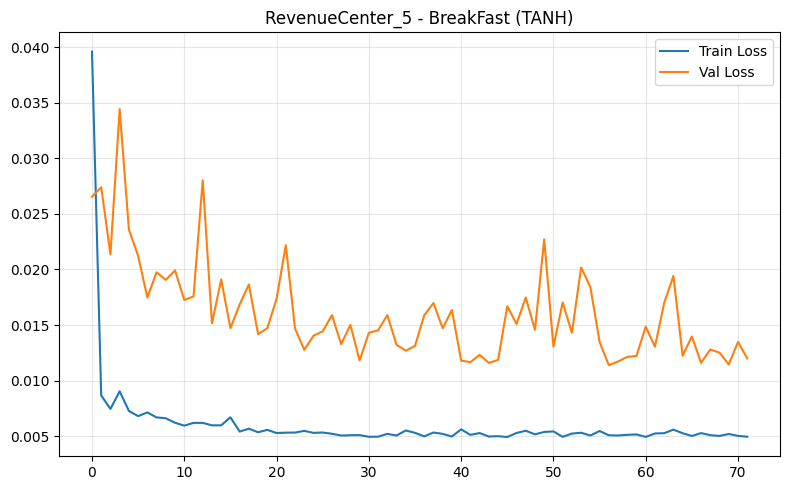

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


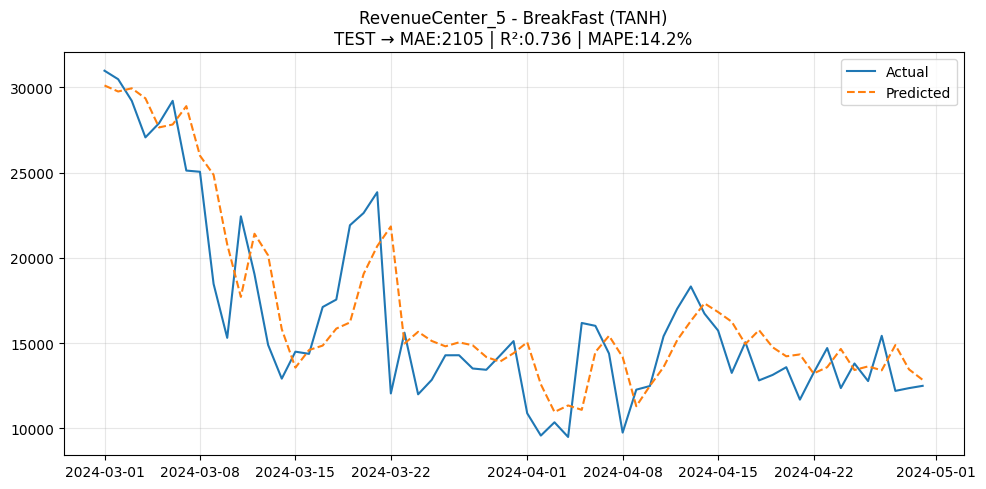

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0221 - val_loss: 0.0202
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0144 - val_loss: 0.0163
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0134 - val_loss: 0.0185
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0163 - val_loss: 0.0186
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0192 - val_loss: 0.0163
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0178 - val_loss: 0.0178
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0123 - val_loss: 0.0166
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0186 - val_loss: 0.0168
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0176 - val_loss: 0.0180
Epoch 10/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0114 - val_loss: 0.0187
Epoch 11/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0156 - val_loss: 0.0200
Epoch 12/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

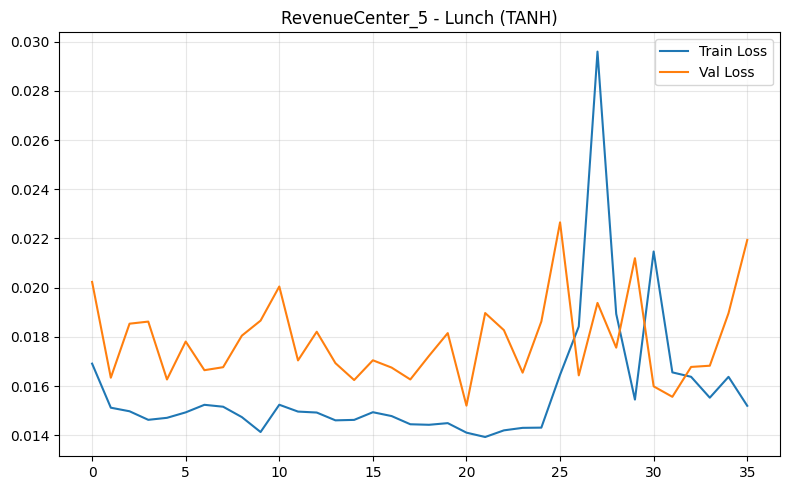

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


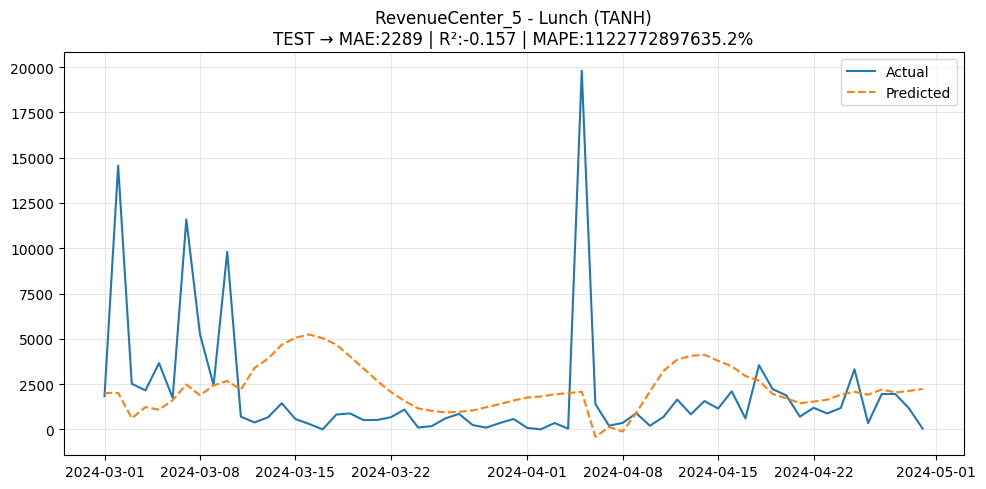

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0308 - val_loss: 0.0620
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0251 - val_loss: 0.0580
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0216 - val_loss: 0.0573
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0186 - val_loss: 0.0633
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0210 - val_loss: 0.0709
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0233 - val_loss: 0.0556
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0197 - val_loss: 0.0687
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0226 - val_loss: 0.0569
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0203 - val_loss: 0.0576
Epoch 10/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0221 - val_loss: 0.0570
Epoch 11/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0195 - val_loss: 0.0620
Epoch 12/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

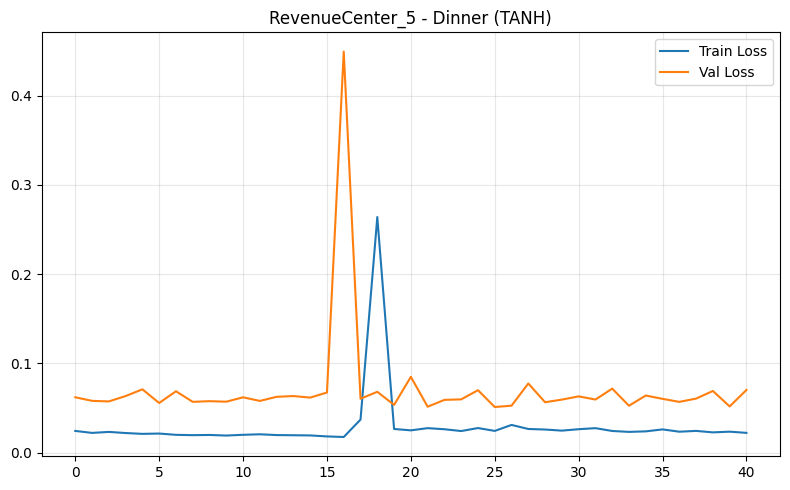

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


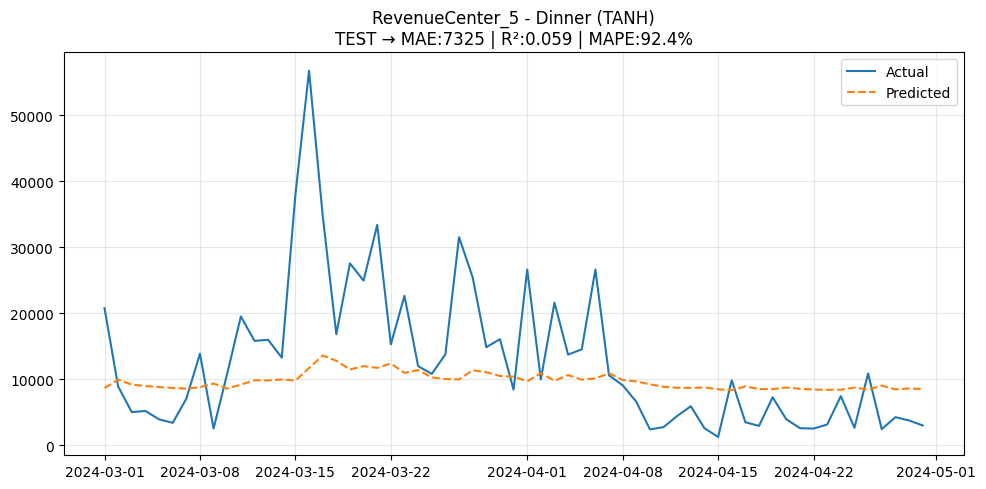

Saved: /content/RevenueCenter_5

Processing: RevenueCenter_7


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0086 - val_loss: 0.0047
Epoch 2/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0104 - val_loss: 0.0047
Epoch 3/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0085 - val_loss: 0.0046
Epoch 4/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0073 - val_loss: 0.0046
Epoch 5/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0101 - val_loss: 0.0045
Epoch 6/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0070 - val_loss: 0.0046
Epoch 7/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0099 - val_loss: 0.0046
Epoch 8/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0081 - val_loss: 0.0076
Epoch 9/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0107 - val_loss: 0.0050
Epoch 10/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0096 - val_loss: 0.0044
Epoch 11/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0101 - val_loss: 0.0046
Epoch 12/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

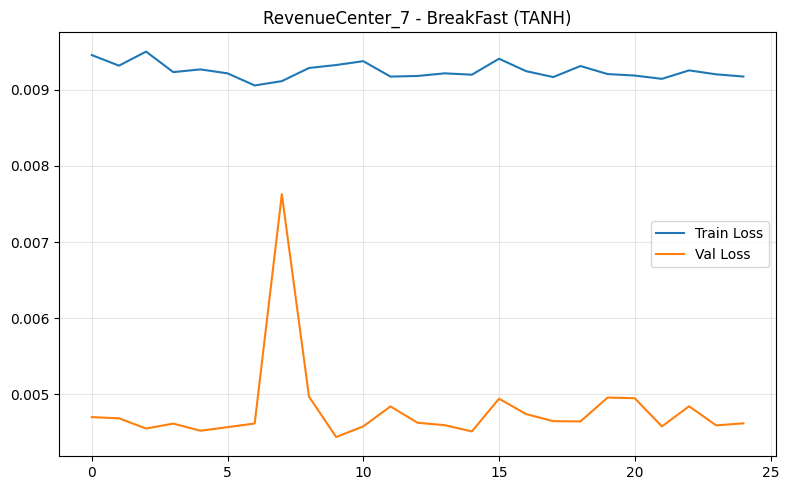

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


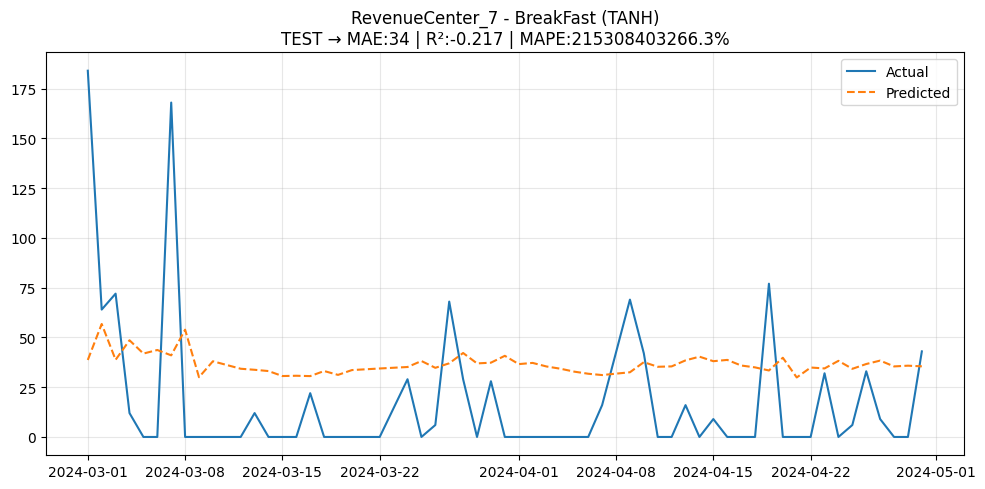

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0133 - val_loss: 0.0431
Epoch 2/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0100 - val_loss: 0.0393
Epoch 3/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0103 - val_loss: 0.0404
Epoch 4/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0099 - val_loss: 0.0390
Epoch 5/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0133 - val_loss: 0.0401
Epoch 6/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0116 - val_loss: 0.0406
Epoch 7/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0094 - val_loss: 0.0400
Epoch 8/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0112 - val_loss: 0.0417
Epoch 9/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0090 - val_loss: 0.0403
Epoch 10/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0160 - val_loss: 0.0402
Epoch 11/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0088 - val_loss: 0.0395
Epoch 12/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

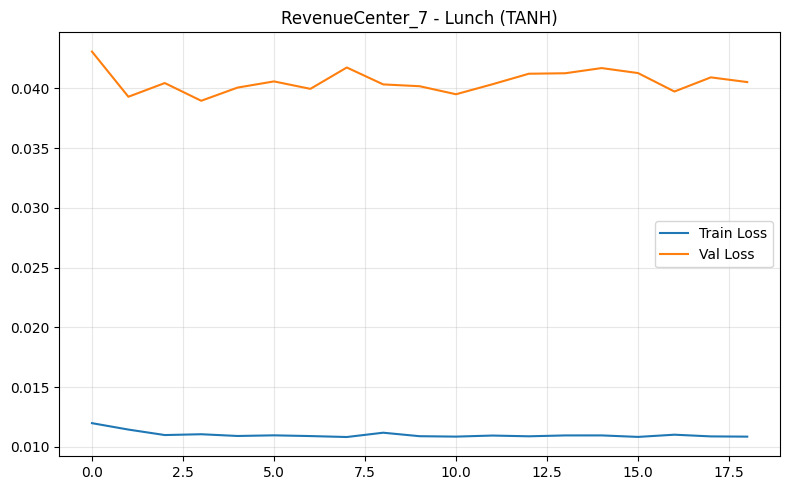

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


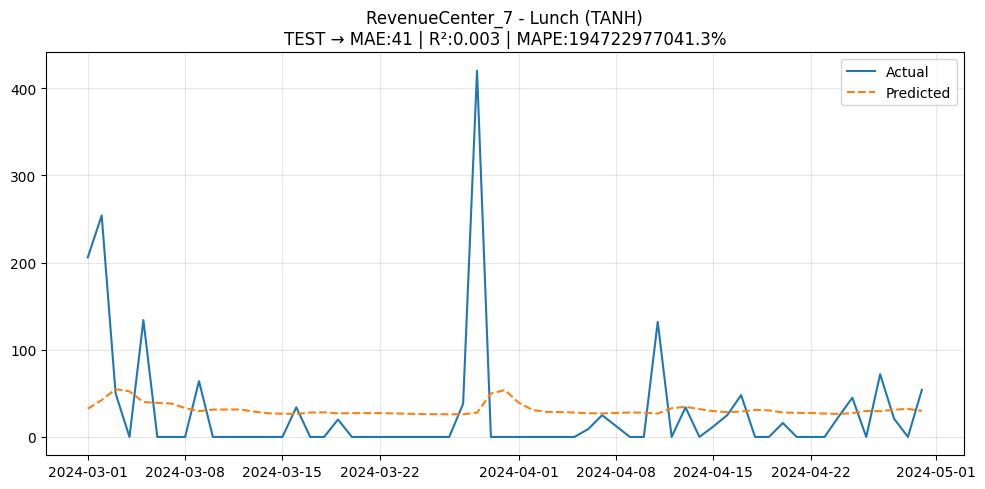

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0438 - val_loss: 0.0979
Epoch 2/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0235 - val_loss: 0.0924
Epoch 3/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0155 - val_loss: 0.0743
Epoch 4/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0188 - val_loss: 0.0812
Epoch 5/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0193 - val_loss: 0.0793
Epoch 6/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0160 - val_loss: 0.0743
Epoch 7/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0172 - val_loss: 0.0848
Epoch 8/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0159 - val_loss: 0.0836
Epoch 9/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0178 - val_loss: 0.0871
Epoch 10/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0151 - val_loss: 0.0785
Epoch 11/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0159 - val_loss: 0.0833
Epoch 12/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

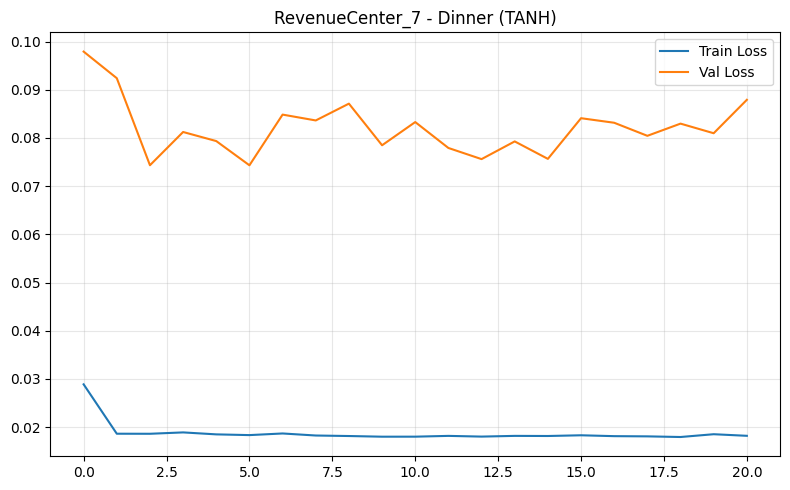

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


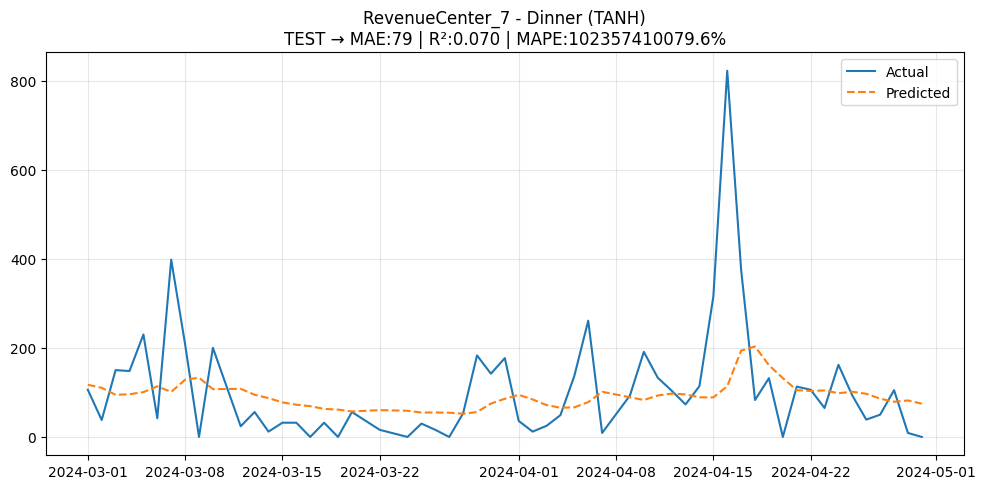

Saved: /content/RevenueCenter_7

Processing: RevenueCenter_2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0430 - val_loss: 0.0229
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0167 - val_loss: 0.0262
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0114 - val_loss: 0.0254
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0122 - val_loss: 0.0255
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0118 - val_loss: 0.0229
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0136 - val_loss: 0.0217
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0212 - val_loss: 0.0314
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0146 - val_loss: 0.0285
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0158 - val_loss: 0.0275
Epoch 10/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0161 - val_loss: 0.0271
Epoch 11/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0198 - val_loss: 0.0277
Epoch 12/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

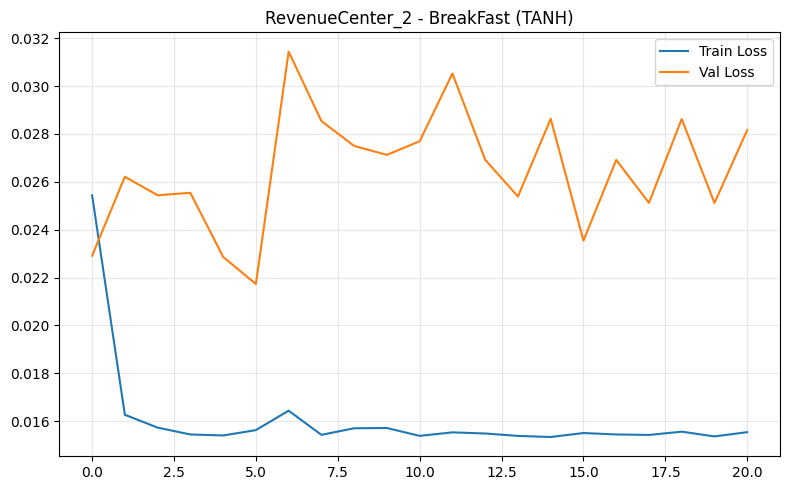

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


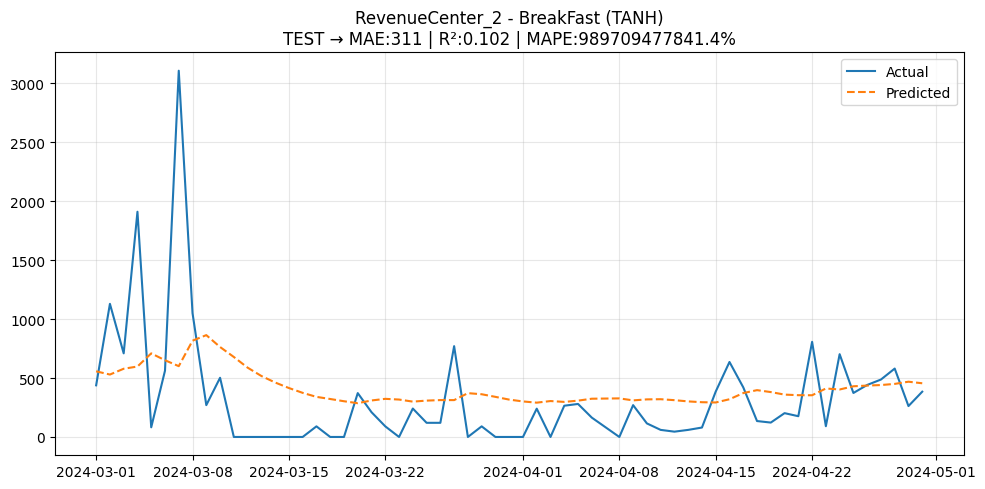

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0179 - val_loss: 0.0550
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0169 - val_loss: 0.0615
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0141 - val_loss: 0.0793
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0171 - val_loss: 0.0681
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0149 - val_loss: 0.0657
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0173 - val_loss: 0.0740
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0187 - val_loss: 0.0785
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0196 - val_loss: 0.0724
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0131 - val_loss: 0.0628
Epoch 10/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0151 - val_loss: 0.0633
Epoch 11/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0125 - val_loss: 0.0652
Epoch 12/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

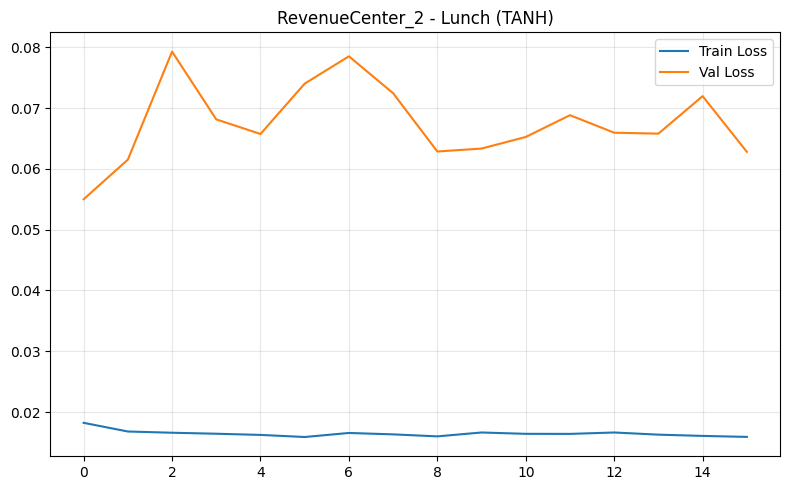

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


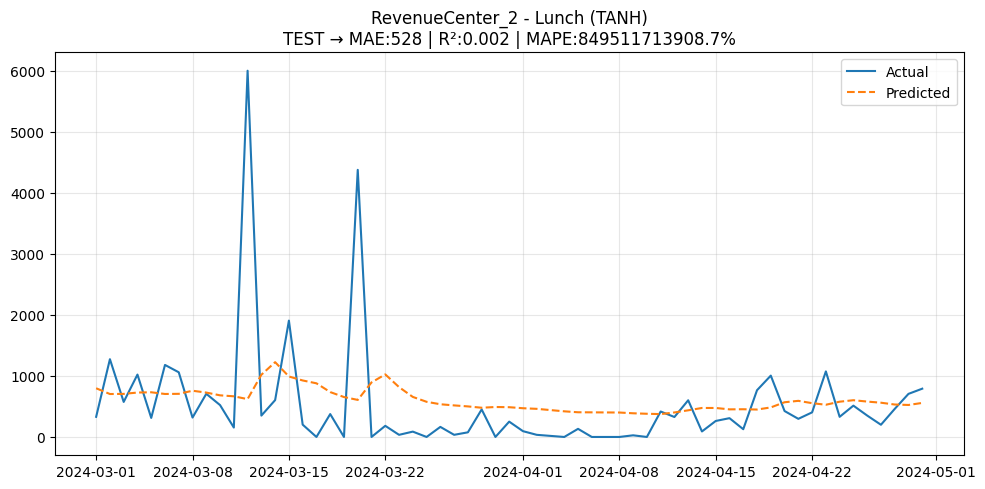

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0019 - val_loss: 0.0271
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0015 - val_loss: 0.0276
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0027 - val_loss: 0.0303
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0026 - val_loss: 0.0291
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0020 - val_loss: 0.0278
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0025 - val_loss: 0.0289
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0020 - val_loss: 0.0276
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0015 - val_loss: 0.0288
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0017 - val_loss: 0.0278
Epoch 10/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0012 - val_loss: 0.0284
Epoch 11/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0022 - val_loss: 0.0266
Epoch 12/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

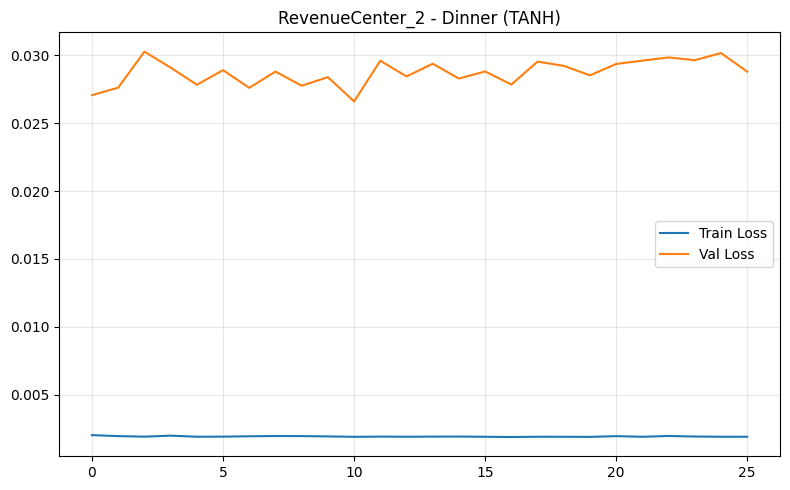

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


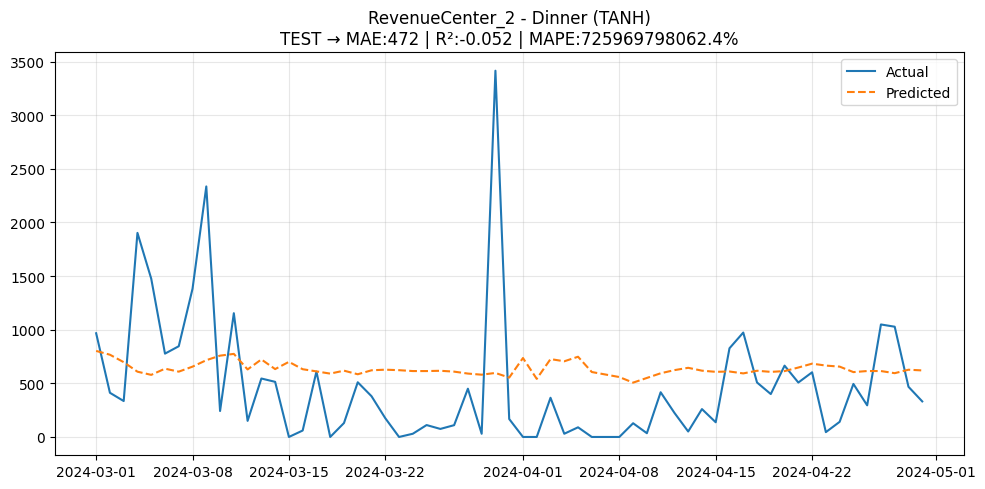

Saved: /content/RevenueCenter_2

Processing: RevenueCenter_1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0080 - val_loss: 0.0278
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0048 - val_loss: 0.0364
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0037 - val_loss: 0.0295
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0046 - val_loss: 0.0379
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0043 - val_loss: 0.0312
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0052 - val_loss: 0.0280
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0046 - val_loss: 0.0300
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0055 - val_loss: 0.0402
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0054 - val_loss: 0.0350
Epoch 10/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0052 - val_loss: 0.0297
Epoch 11/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0064 - val_loss: 0.0321
Epoch 12/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

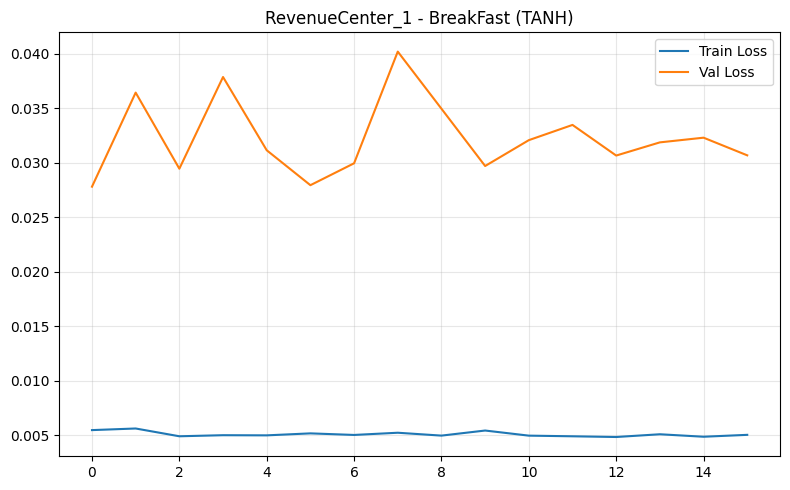

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


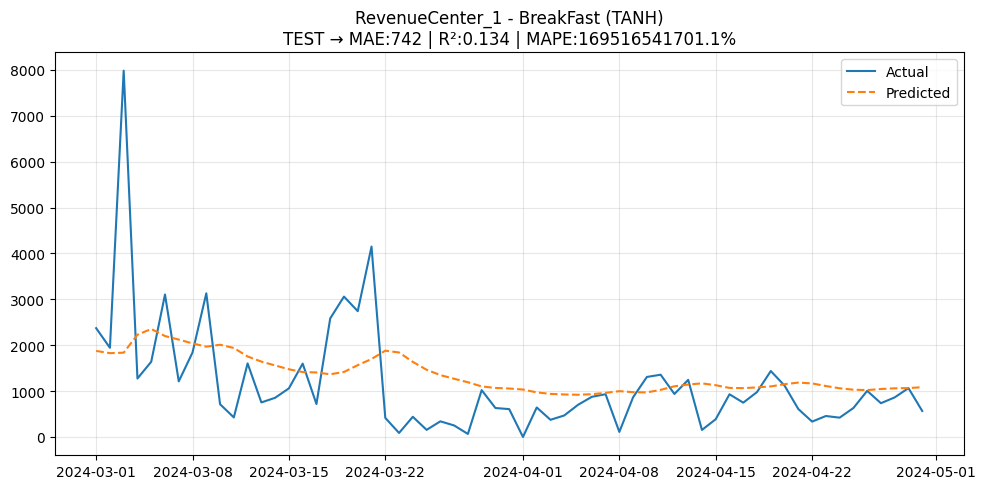

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0181 - val_loss: 0.0744
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0141 - val_loss: 0.0785
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0101 - val_loss: 0.0576
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0189 - val_loss: 0.0770
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0124 - val_loss: 0.0606
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0121 - val_loss: 0.0703
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0126 - val_loss: 0.0773
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0080 - val_loss: 0.0644
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0088 - val_loss: 0.0666
Epoch 10/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0081 - val_loss: 0.0710
Epoch 11/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0086 - val_loss: 0.0628
Epoch 12/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

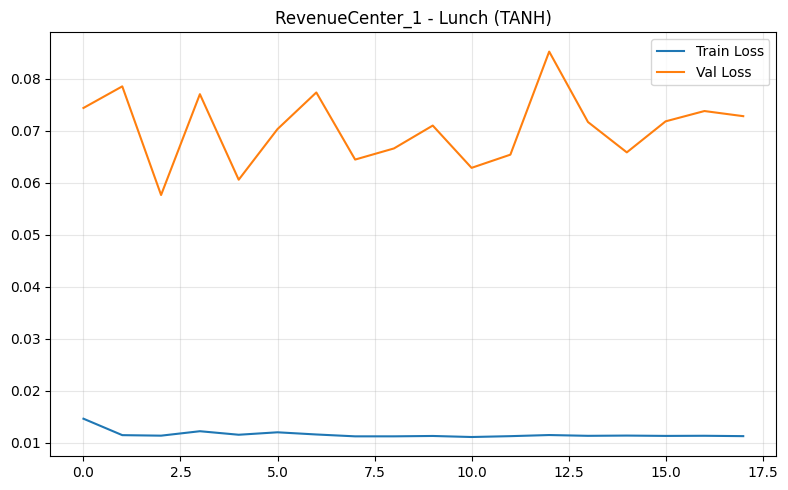

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


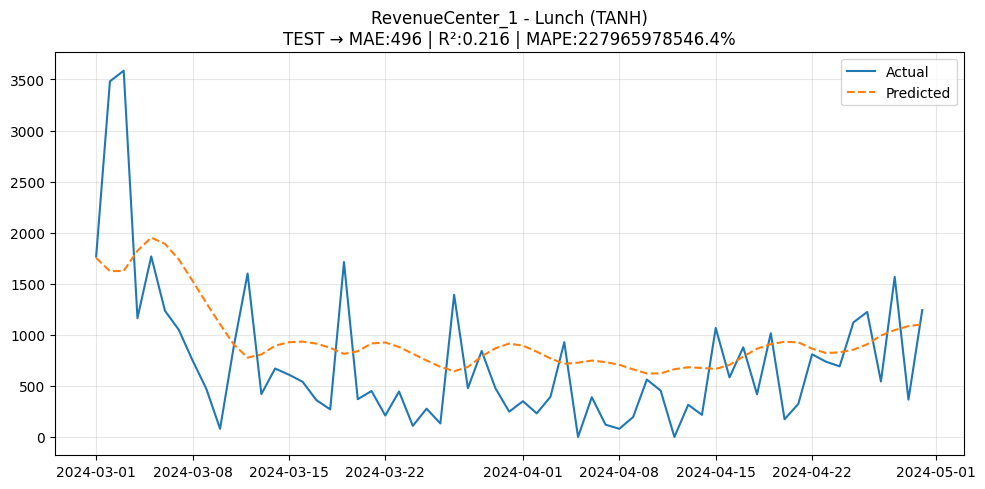

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0319 - val_loss: 0.0500
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0104 - val_loss: 0.0262
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0098 - val_loss: 0.0314
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0100 - val_loss: 0.0265
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0102 - val_loss: 0.0374
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0112 - val_loss: 0.0359
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0107 - val_loss: 0.0322
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0096 - val_loss: 0.0358
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0122 - val_loss: 0.0285
Epoch 10/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0132 - val_loss: 0.0320
Epoch 11/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0137 - val_loss: 0.0280
Epoch 12/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

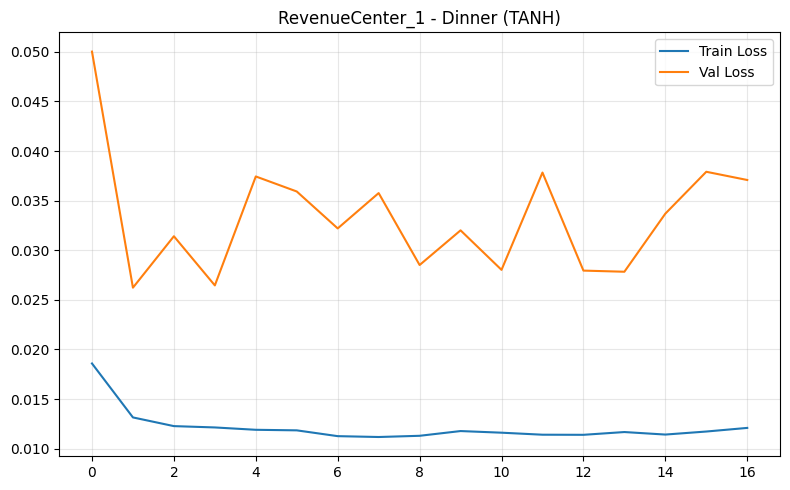

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


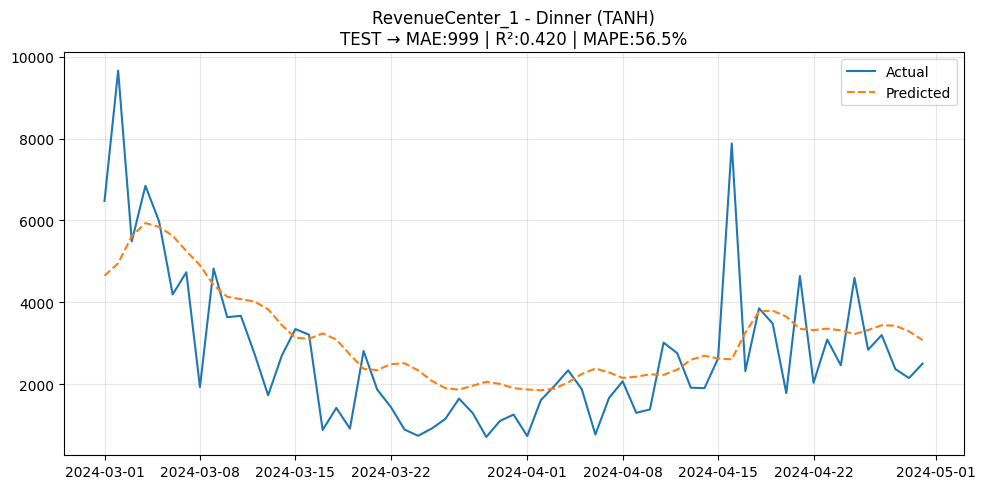

Saved: /content/RevenueCenter_1

Processing: RevenueCenter_6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0240 - val_loss: 0.0496
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0185 - val_loss: 0.0518
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0260 - val_loss: 0.0533
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0274 - val_loss: 0.0508
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0241 - val_loss: 0.0505
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0239 - val_loss: 0.0502
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0206 - val_loss: 0.0515
Epoch 8/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0229 - val_loss: 0.0505
Epoch 9/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0202 - val_loss: 0.0497
Epoch 10/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0199 - val_loss: 0.0528
Epoch 11/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0177 - val_loss: 0.0507
Epoch 12/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

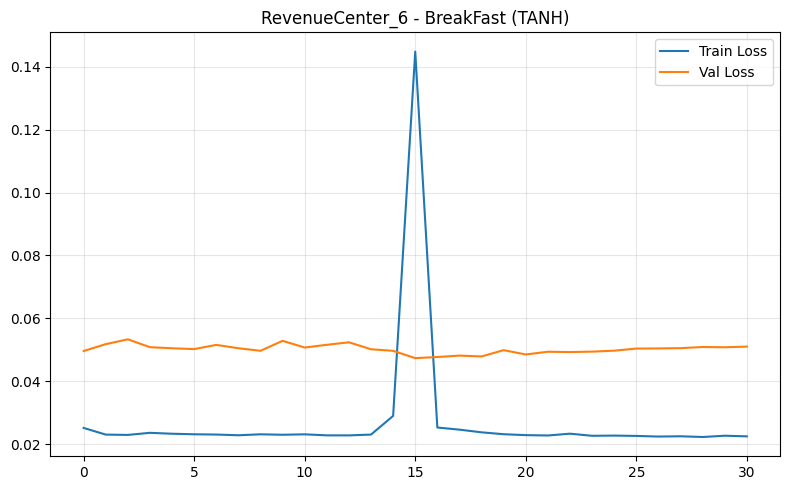

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


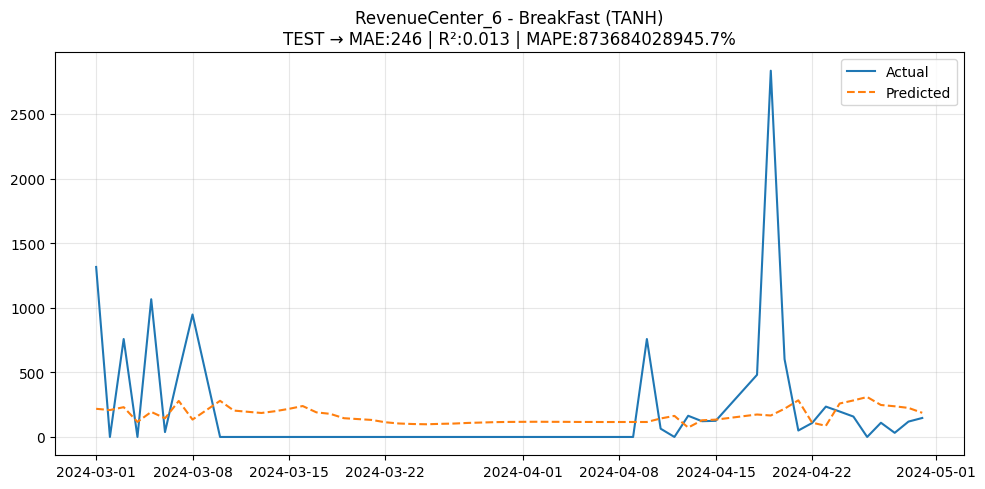

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0182 - val_loss: 0.0186
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0158 - val_loss: 0.0196
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0109 - val_loss: 0.0190
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0108 - val_loss: 0.0194
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0130 - val_loss: 0.0188
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0092 - val_loss: 0.0262
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0114 - val_loss: 0.0224
Epoch 8/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0093 - val_loss: 0.0207
Epoch 9/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0092 - val_loss: 0.0197
Epoch 10/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0088 - val_loss: 0.0191
Epoch 11/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0097 - val_loss: 0.0198
Epoch 12/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

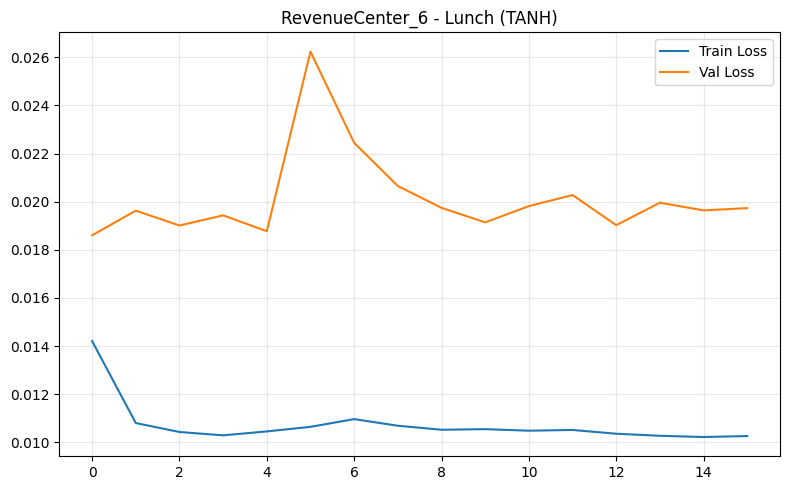

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


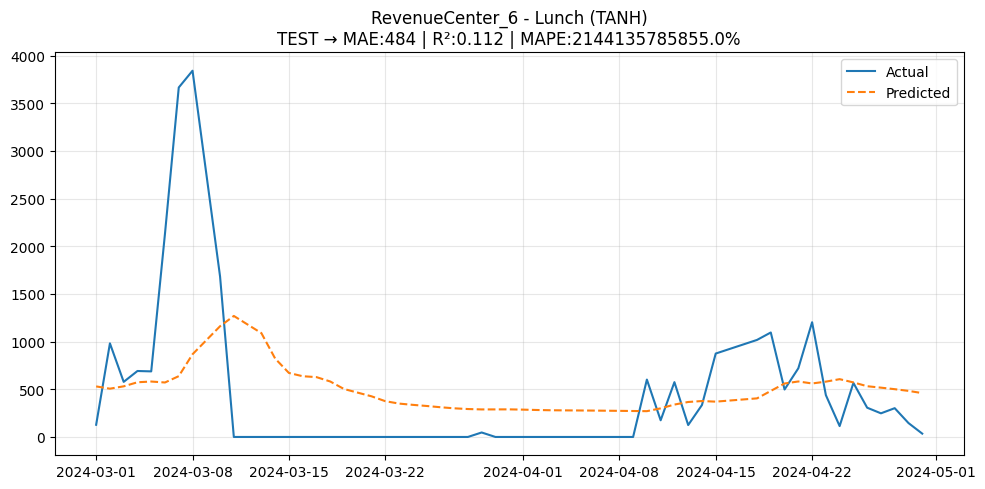

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0033 - val_loss: 0.0254
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0072 - val_loss: 0.0250
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0026 - val_loss: 0.0247
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0052 - val_loss: 0.0253
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0027 - val_loss: 0.0252
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0013 - val_loss: 0.0249
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0048 - val_loss: 0.0248
Epoch 8/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0058 - val_loss: 0.0252
Epoch 9/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0023 - val_loss: 0.0249
Epoch 10/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0037 - val_loss: 0.0251
Epoch 11/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0030 - val_loss: 0.0246
Epoch 12/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

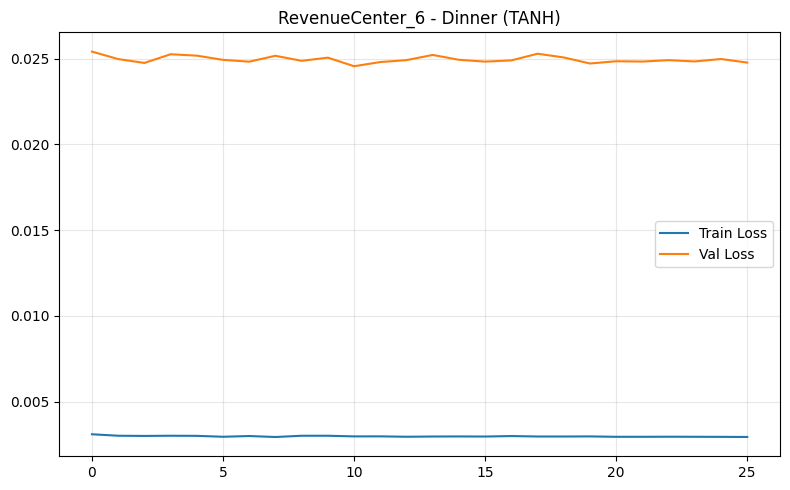

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


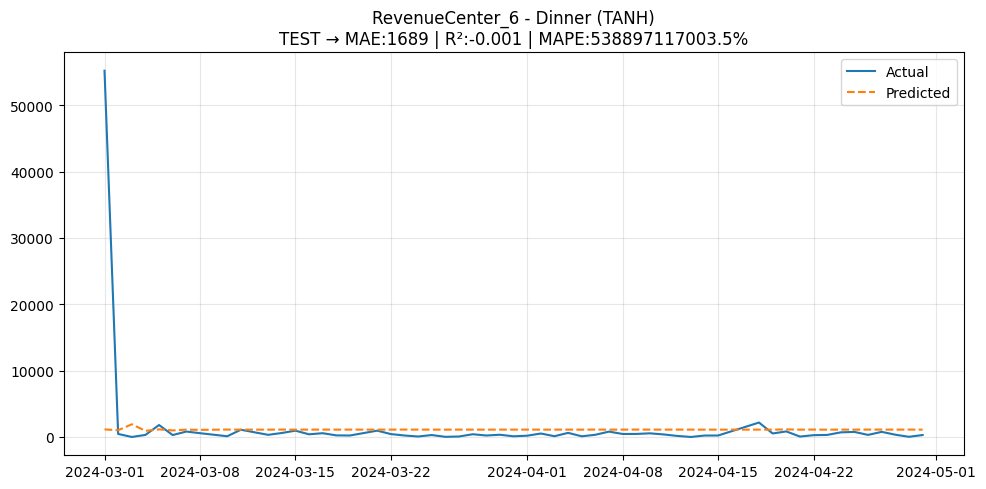

Saved: /content/RevenueCenter_6

Processing: RevenueCenter_4
Skipping RevenueCenter_4 - BreakFast (constant values)
Skipping RevenueCenter_4 - Lunch (constant values)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 3.0222e-04 - val_loss: 3.7065e-04
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0094 - val_loss: 1.0114e-06
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0010 - val_loss: 4.2146e-05
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.0138e-04 - val_loss: 1.1567e-04
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0051 - val_loss: 1.3919e-06
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0044 - val_loss: 1.9631e-07
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0054 - val_loss: 6.4389e-07
Epoch 8/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0095 - val_loss: 8.8030e-07
Epoch 9/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0024 - val_loss: 2.3505e-06
Epoch 10/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.9345e-04 - val_loss: 8.2592e-05
Epoch 11/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0012 - val_loss: 2.9635e

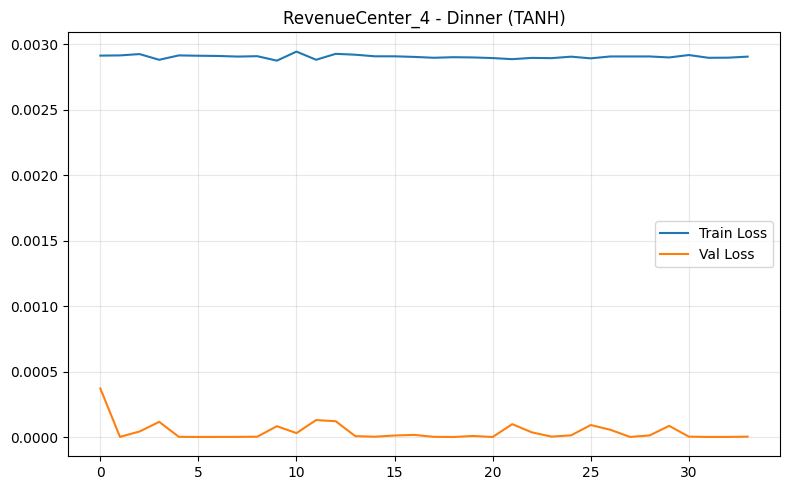

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


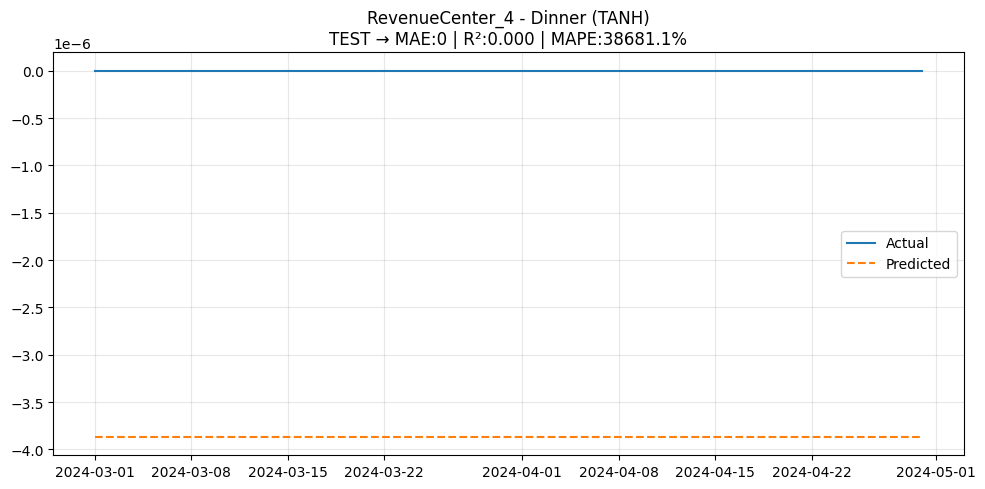

Saved: /content/RevenueCenter_4

Processing: RevenueCenter_8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0071 - val_loss: 0.0025
Epoch 2/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0074 - val_loss: 0.0026
Epoch 3/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0077 - val_loss: 0.0025
Epoch 4/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0057 - val_loss: 0.0027
Epoch 5/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0089 - val_loss: 0.0026
Epoch 6/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0111 - val_loss: 0.0024
Epoch 7/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0059 - val_loss: 0.0024
Epoch 8/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0063 - val_loss: 0.0025
Epoch 9/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0136 - val_loss: 0.0025
Epoch 10/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0175 - val_loss: 0.0024
Epoch 11/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0152 - val_loss: 0.0024
Epoch 12/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

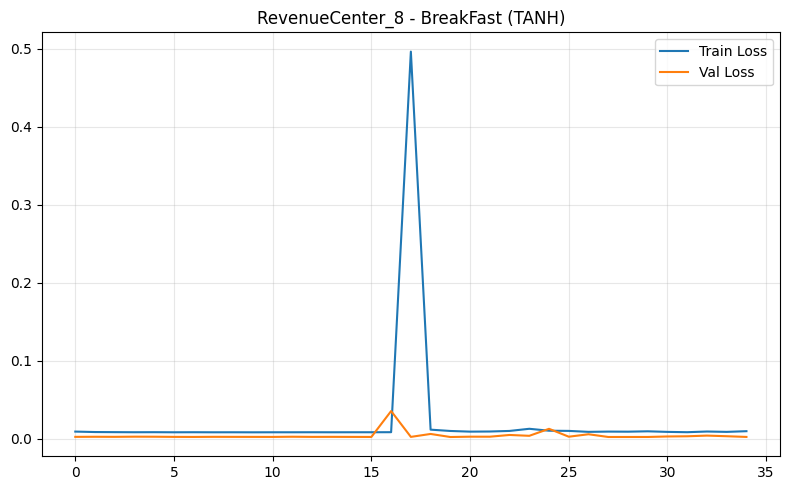

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


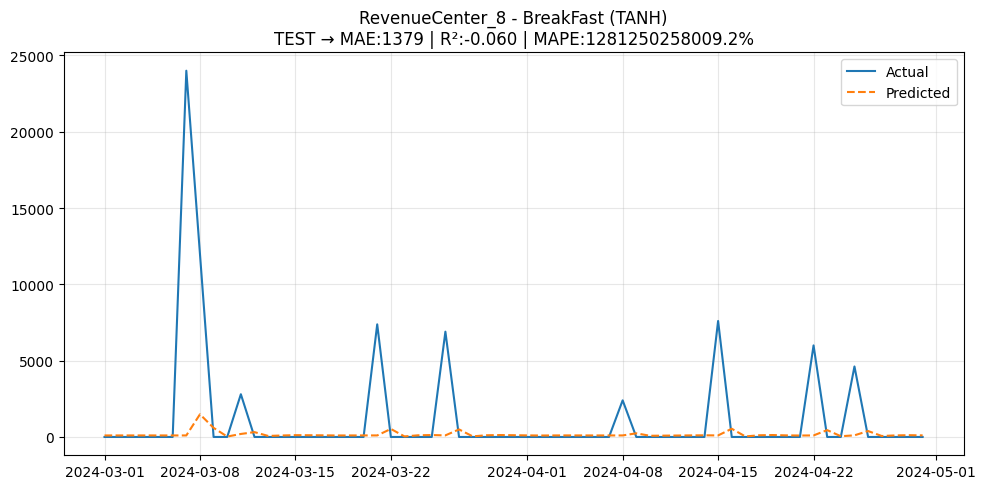

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0120 - val_loss: 0.0970
Epoch 2/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0133 - val_loss: 0.1026
Epoch 3/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0146 - val_loss: 0.0993
Epoch 4/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0158 - val_loss: 0.0983
Epoch 5/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0158 - val_loss: 0.0979
Epoch 6/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0132 - val_loss: 0.1067
Epoch 7/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0186 - val_loss: 0.0905
Epoch 8/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0201 - val_loss: 0.0981
Epoch 9/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0139 - val_loss: 0.0982
Epoch 10/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0120 - val_loss: 0.0966
Epoch 11/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0135 - val_loss: 0.0935
Epoch 12/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

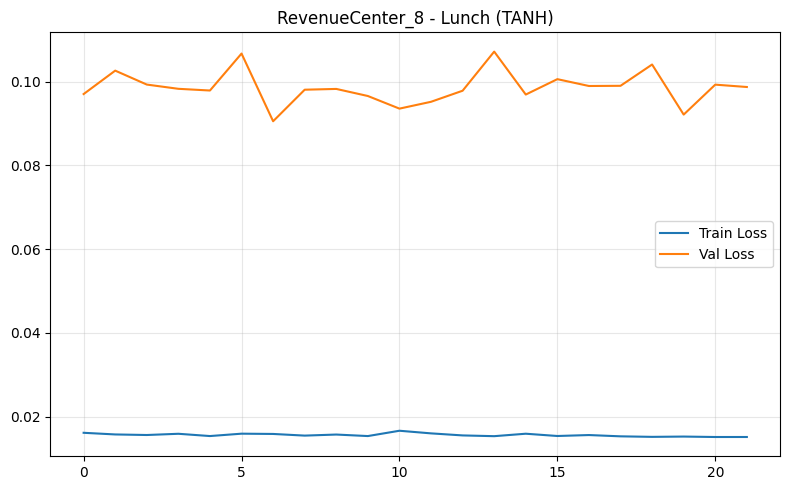

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


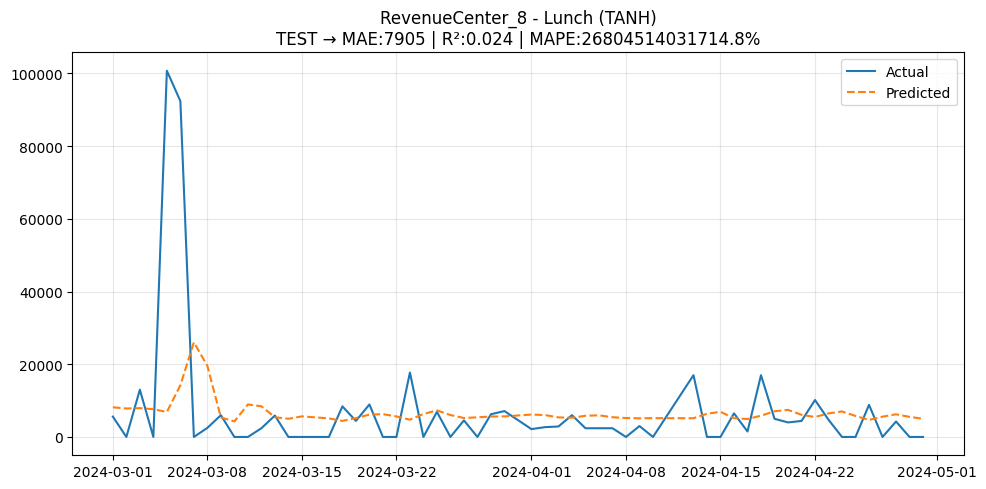

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0170 - val_loss: 0.0649
Epoch 2/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0144 - val_loss: 0.0584
Epoch 3/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0146 - val_loss: 0.0564
Epoch 4/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0104 - val_loss: 0.0589
Epoch 5/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0158 - val_loss: 0.0640
Epoch 6/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0127 - val_loss: 0.0592
Epoch 7/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0091 - val_loss: 0.0577
Epoch 8/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0119 - val_loss: 0.0598
Epoch 9/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0122 - val_loss: 0.0604
Epoch 10/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0098 - val_loss: 0.0556
Epoch 11/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0148 - val_loss: 0.0571
Epoch 12/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

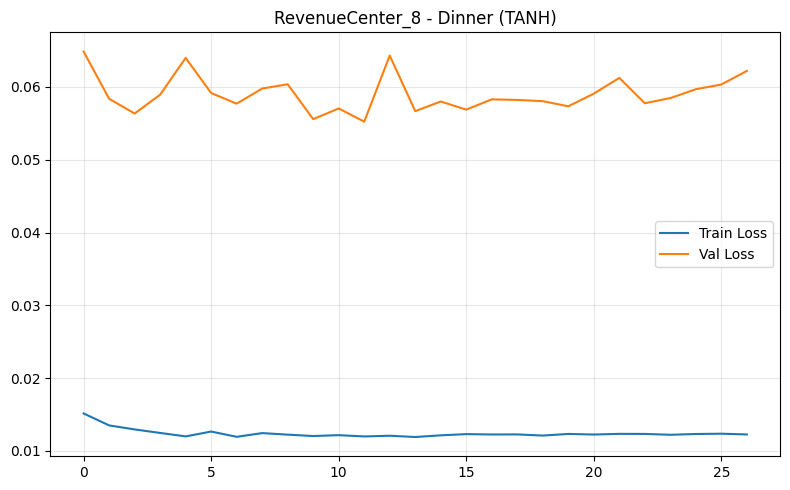

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


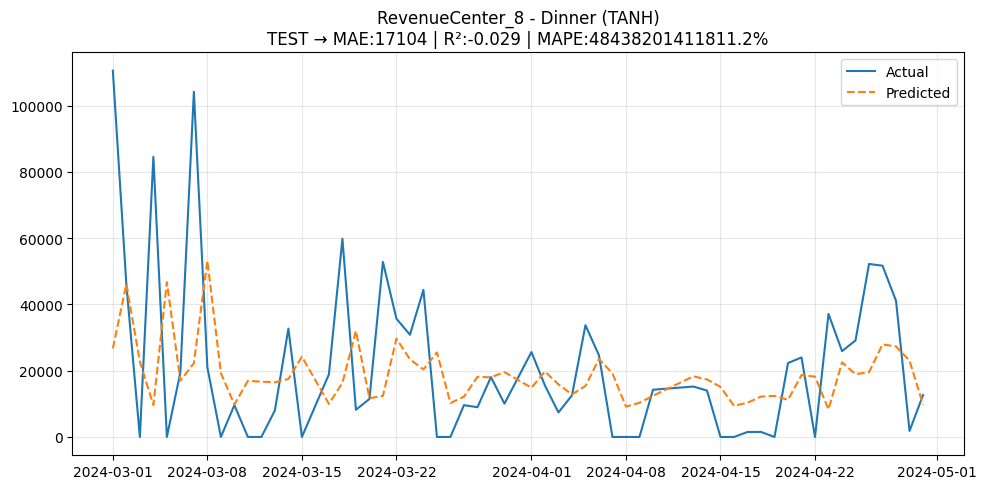

Saved: /content/RevenueCenter_8

Processing: RevenueCenter_3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0306 - val_loss: 0.0376
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0243 - val_loss: 0.0417
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0219 - val_loss: 0.0370
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0206 - val_loss: 0.0420
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0253 - val_loss: 0.0394
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0235 - val_loss: 0.0420
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0211 - val_loss: 0.0402
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0234 - val_loss: 0.0416
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0265 - val_loss: 0.0410
Epoch 10/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0239 - val_loss: 0.0395
Epoch 11/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0226 - val_loss: 0.0378
Epoch 12/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

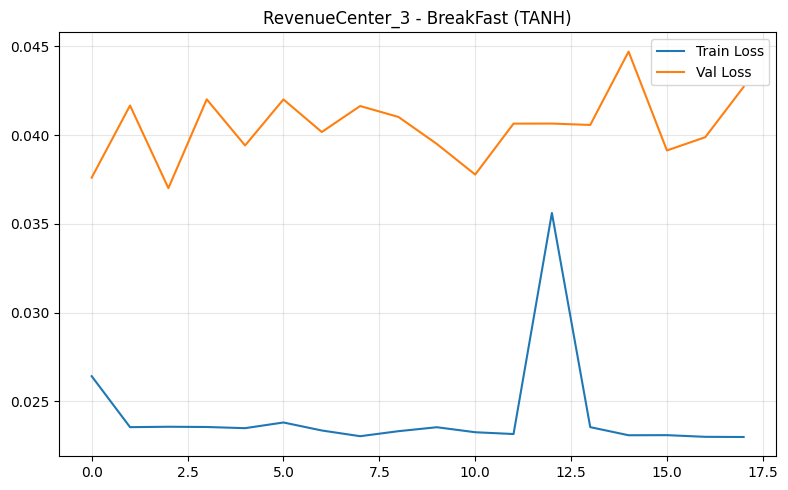

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


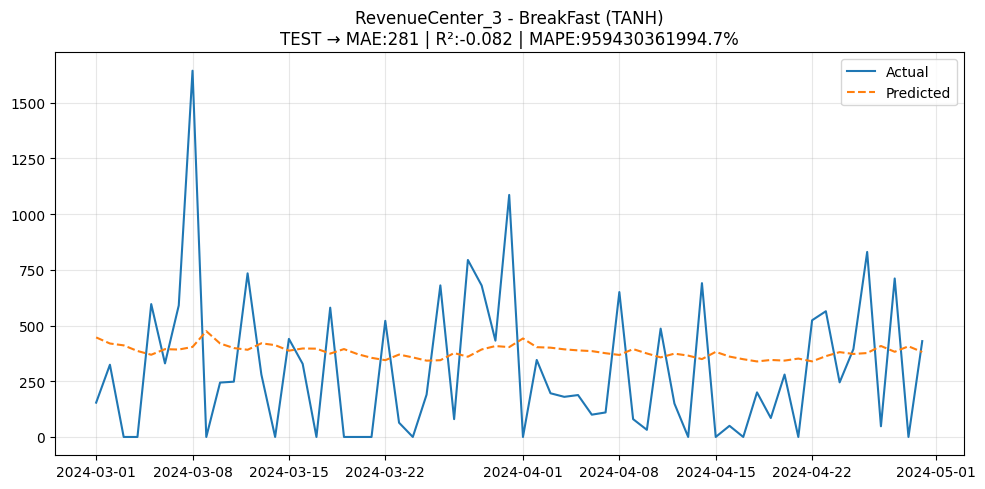

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0134 - val_loss: 0.0551
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0123 - val_loss: 0.0508
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0108 - val_loss: 0.0573
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0090 - val_loss: 0.0473
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0091 - val_loss: 0.0604
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0088 - val_loss: 0.0578
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0094 - val_loss: 0.0591
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0091 - val_loss: 0.0546
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0116 - val_loss: 0.0599
Epoch 10/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0108 - val_loss: 0.0600
Epoch 11/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0082 - val_loss: 0.0651
Epoch 12/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

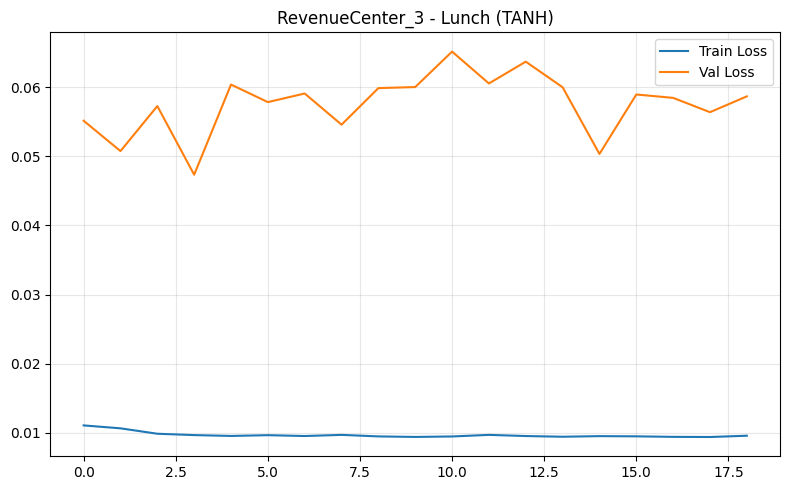

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


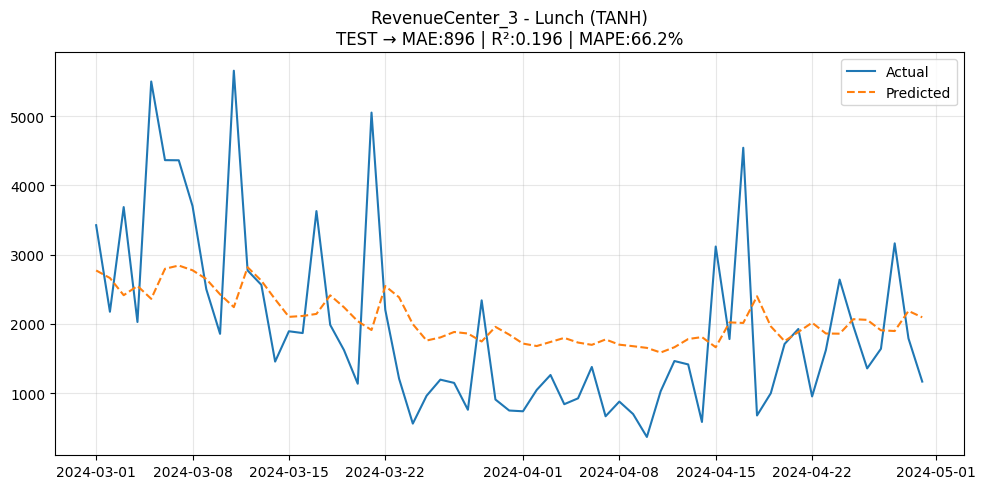

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0140 - val_loss: 0.0401
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0110 - val_loss: 0.0459
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0097 - val_loss: 0.0418
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0110 - val_loss: 0.0470
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0091 - val_loss: 0.0609
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0086 - val_loss: 0.0590
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0092 - val_loss: 0.0727
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0091 - val_loss: 0.0532
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0088 - val_loss: 0.0512
Epoch 10/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0086 - val_loss: 0.0470
Epoch 11/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0082 - val_loss: 0.0459
Epoch 12/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

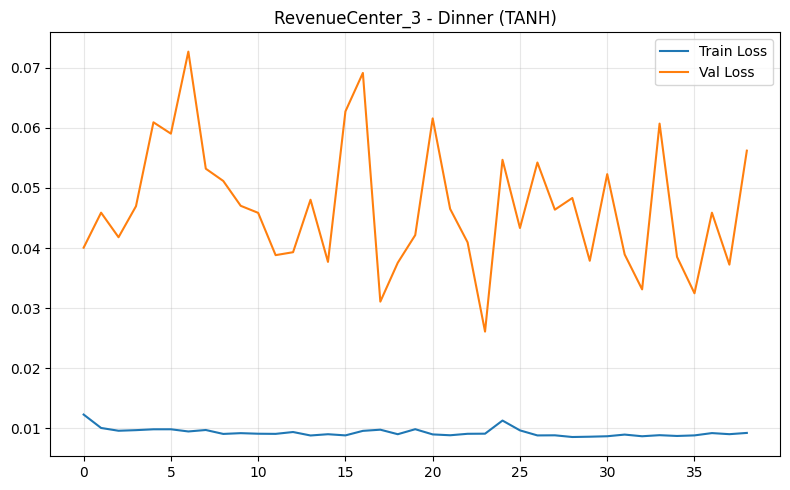

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


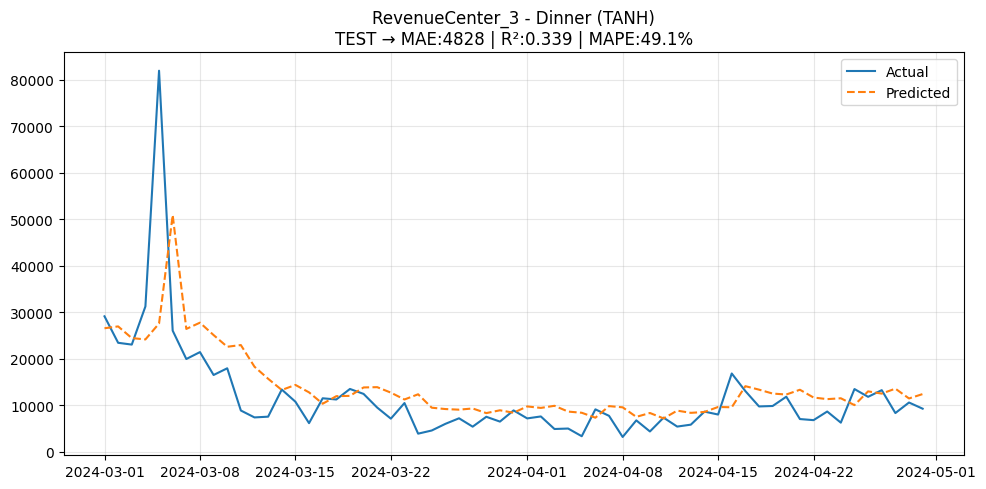

Saved: /content/RevenueCenter_3

Processing: RevenueCenter_9


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0101 - val_loss: 0.0771
Epoch 2/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0109 - val_loss: 0.0755
Epoch 3/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0106 - val_loss: 0.0746
Epoch 4/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0098 - val_loss: 0.0718
Epoch 5/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0073 - val_loss: 0.0637
Epoch 6/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0103 - val_loss: 0.0703
Epoch 7/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0083 - val_loss: 0.0696
Epoch 8/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0100 - val_loss: 0.0716
Epoch 9/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0110 - val_loss: 0.0709
Epoch 10/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0121 - val_loss: 0.0756
Epoch 11/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0085 - val_loss: 0.0733
Epoch 12/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

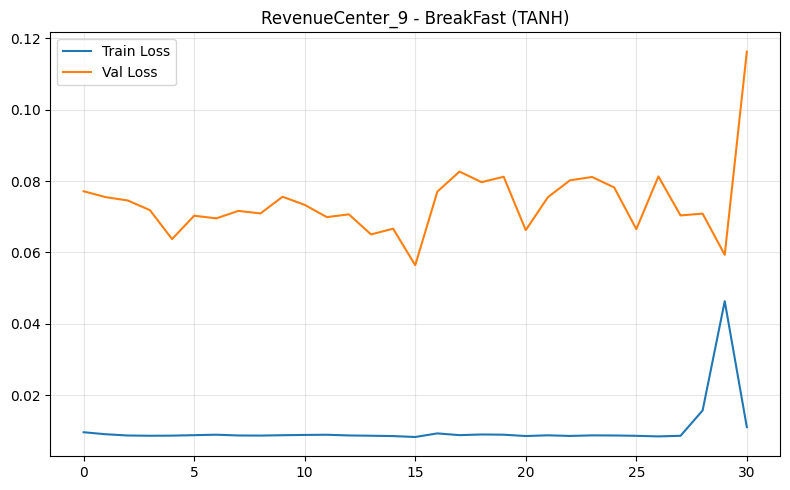

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


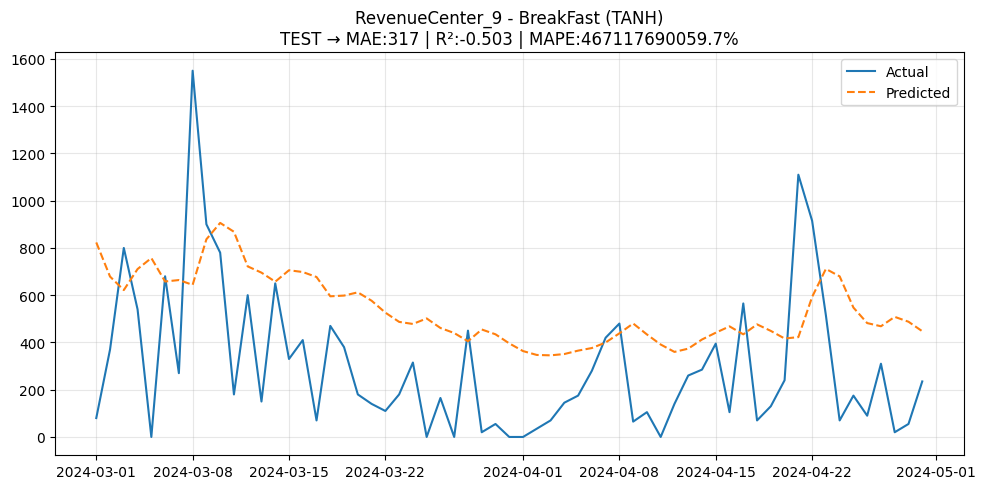

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0364 - val_loss: 0.0464
Epoch 2/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0293 - val_loss: 0.0522
Epoch 3/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0329 - val_loss: 0.0477
Epoch 4/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0268 - val_loss: 0.0434
Epoch 5/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0364 - val_loss: 0.0463
Epoch 6/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0287 - val_loss: 0.0463
Epoch 7/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0255 - val_loss: 0.0446
Epoch 8/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0276 - val_loss: 0.0434
Epoch 9/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0292 - val_loss: 0.0453
Epoch 10/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0344 - val_loss: 0.0411
Epoch 11/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0307 - val_loss: 0.0400
Epoch 12/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

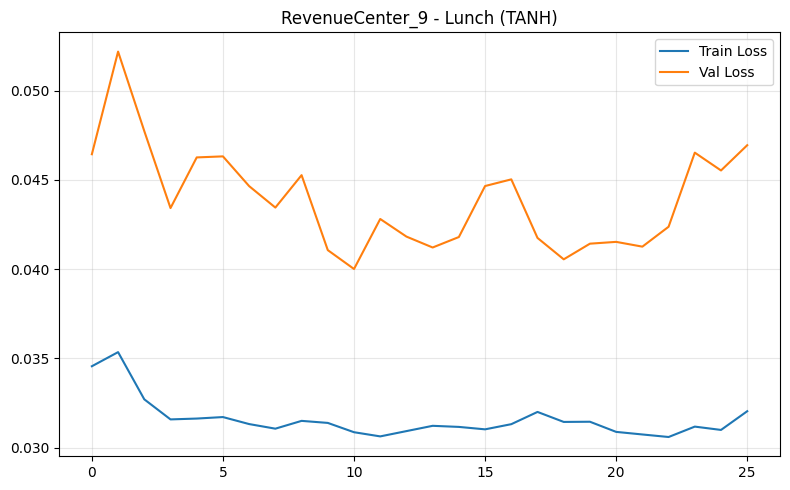

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


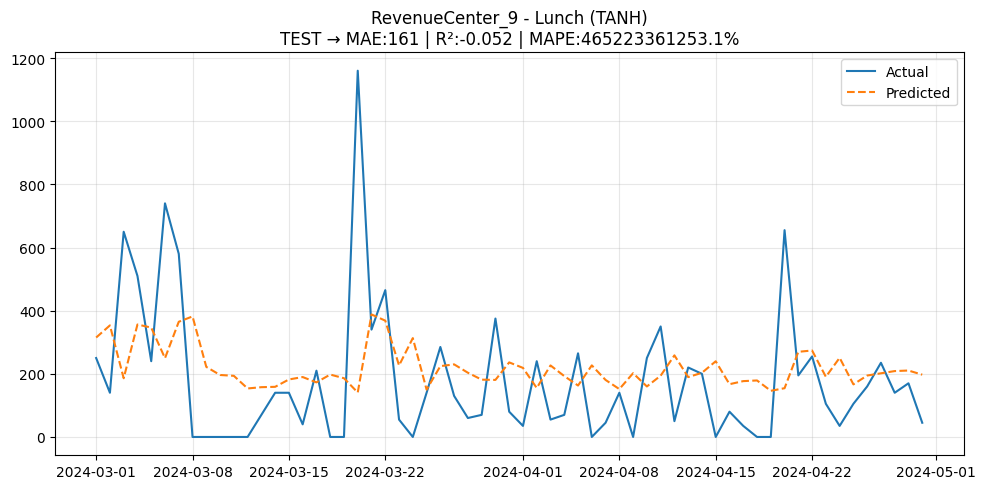

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0309 - val_loss: 0.0138
Epoch 2/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0269 - val_loss: 0.0152
Epoch 3/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0185 - val_loss: 0.0151
Epoch 4/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0161 - val_loss: 0.0167
Epoch 5/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0198 - val_loss: 0.0159
Epoch 6/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0210 - val_loss: 0.0162
Epoch 7/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0205 - val_loss: 0.0154
Epoch 8/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0178 - val_loss: 0.0147
Epoch 9/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0226 - val_loss: 0.0154
Epoch 10/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0223 - val_loss: 0.0142
Epoch 11/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0237 - val_loss: 0.0142
Epoch 12/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

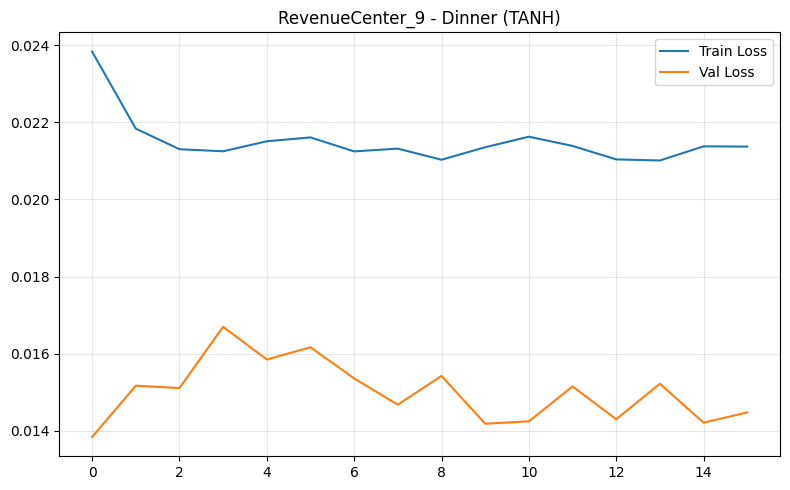

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


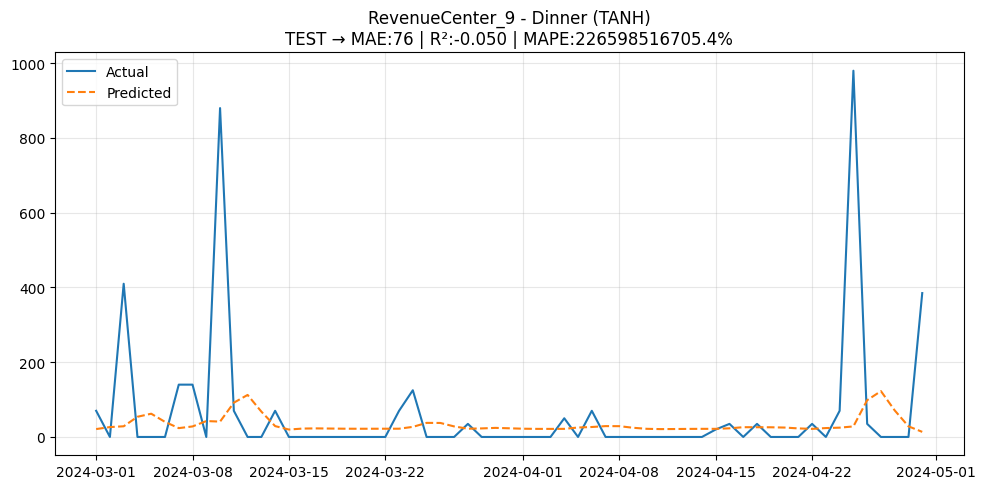

Saved: /content/RevenueCenter_9

ALL CENTERS COMPLETED — TANH MODEL


In [14]:
for file in files:

    center_name = os.path.basename(file).replace(".xlsx", "")
    print("\nProcessing:", center_name)

    center_path = os.path.join(output_folder, center_name)
    os.makedirs(center_path, exist_ok=True)

    df = pd.read_excel(file)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    split_date = df["Date"].max() - pd.DateOffset(months=2)
    meals = ["BreakFast", "Lunch", "Dinner"]

    for meal in meals:

        temp_df = df[["Date", meal]].copy()
        temp_df.rename(columns={meal: "y"}, inplace=True)

        train_df = temp_df[temp_df["Date"] <= split_date]
        test_df  = temp_df[temp_df["Date"] > split_date]

        if train_df["y"].nunique() <= 1:
            print(f"Skipping {center_name} - {meal} (constant values)")
            continue

        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_df[["y"]])
        test_scaled  = scaler.transform(test_df[["y"]])

        WINDOW = 30
        X_train, y_train = create_sequences(train_scaled, WINDOW)
        combined = np.vstack([train_scaled[-WINDOW:], test_scaled])
        X_test, y_test = create_sequences(combined, WINDOW)

        X_train = X_train.reshape(-1, WINDOW, 1)
        X_test  = X_test.reshape(-1, WINDOW, 1)

        # =========================
        # MODEL — TANH
        # =========================
        model = Sequential([
            LSTM(
                1024,
                activation="tanh",
                recurrent_activation="sigmoid",
                input_shape=(WINDOW, 1)
            ),
            Dense(1)
        ])

        model.compile(optimizer="adam", loss="mse")

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            epochs=200,
            batch_size=8,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=1
        )

        # =========================
        # LOSS PLOT
        # =========================
        plt.figure(figsize=(8,5))
        plt.plot(history.history["loss"], label="Train Loss")
        plt.plot(history.history["val_loss"], label="Val Loss")
        plt.title(f"{center_name} - {meal} (TANH)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_loss_tanh.png"), dpi=300)
        plt.show()
        plt.close()

        # =========================
        # PREDICTIONS
        # =========================
        y_train_pred = scaler.inverse_transform(model.predict(X_train))
        y_test_pred  = scaler.inverse_transform(model.predict(X_test))
        y_train_true = scaler.inverse_transform(y_train.reshape(-1,1))
        y_test_true  = scaler.inverse_transform(y_test.reshape(-1,1))

        train_mae  = mean_absolute_error(y_train_true, y_train_pred)
        train_r2   = r2_score(y_train_true, y_train_pred)
        train_mape = mape(y_train_true, y_train_pred)

        test_mae  = mean_absolute_error(y_test_true, y_test_pred)
        test_r2   = r2_score(y_test_true, y_test_pred)
        test_mape = mape(y_test_true, y_test_pred)

        plt.figure(figsize=(10,5))
        plt.plot(test_df["Date"], y_test_true, label="Actual")
        plt.plot(test_df["Date"], y_test_pred, "--", label="Predicted")
        plt.title(
            f"{center_name} - {meal} (TANH)\n"
            f"TEST → MAE:{test_mae:.0f} | R²:{test_r2:.3f} | MAPE:{test_mape:.1f}%"
        )
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_pred_tanh.png"), dpi=300)
        plt.show()
        plt.close()

    print("Saved:", center_path)

print("\nALL CENTERS COMPLETED — TANH MODEL")

In [ ]:
y_min = y_train.min()
y_max = y_train.max()

print("Target range:", y_min, "to", y_max)
print("Range width:", y_max - y_min)

Target range: 0.0 to 37870.0
Range width: 37870.0
